# Introduction

This repository presents a fully reproducible, GPU-accelerated financial news sentiment analysis and price-direction prediction pipeline deployed on Databricks Serverless GPU. AAPL news articles and market data are ingested into a Delta Lakehouse workflow and processed through an advanced natural language processing (NLP) stack consisting of HTML normalization, text preprocessing, entity-aware sentence segmentation, and neural coreference resolution. FinBERT is applied at the sentence level to generate financial sentiment features, which are averaged across dates and combined with technical indicators (normalized close, RSI, OBV differentials) to construct a supervised learning dataset for 5-day price-direction forecasting.

An XGBoost classifier, trained with and without sentiment features, is used to evaluate whether FinBERT-derived sentiment improves predictive accuracy. Sentiment analysis does not improve out-of-sample accuracy because of sensitivity to tone and the presence of multiple tickers in the same article, indicating that sentiment provides contextual—but noisy—information. This repository provides the complete Databricks implementation, project documentation, and experimental workflow.

**Note: Requires Databricks Serverless GPU A10 Compute with AI v4 Environment.**

**Ensure you have raw dataset loaded in the Volume Catalog before running the notebook**

# Dependency Installation

Install required NLP and utility packages (spaCy, regex helpers, fastcoref, etc.)

Restarting the cluster kernel ensures newly installed Python libraries are properly loaded.

In [0]:
# --- Upgrade pip and restart Python so new packages are picked up cleanly ---
%pip install --upgrade pip
dbutils.library.restartPython()

# --- Install NLP and coreference libraries used later in the pipeline ---
%pip install "textacy==0.13.0" fastcoref hf_transfer huggingface_hub ta
dbutils.library.restartPython()

# --- Load spaCy and prefer GPU execution when available for faster NLP ---
import spacy
spacy.prefer_gpu()

# --- Download small English spaCy model used for basic NLP tasks ---
import spacy.cli; spacy.cli.download("en_core_web_sm")
dbutils.library.restartPython()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 21.6 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 25.0.1
    Uninstalling pip-25.0.1:
      Successfully uninstalled pip-25.0.1
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
DEPRECATION: Using the pkg_resources metadata backend is deprecated. pip 26.3 will enforce this behaviour change. A possible replacement is to use the default importlib.metadata backend, by unsetting the _PIP_USE_IMPORTLIB_METADATA environment variable. Discussion can be found at https://github.com/pypa/pip/issues/13317
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Ins

/databricks/python/lib/python3.12/site-packages/torch/__init__.py:2064: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  _C._initExtension(_manager_path())
DEPRECATION: Using the pkg_resources metadata backend is deprecated. pip 26.3 will enforce this behaviour change. A possible replacement is to use the default importlib.metadata backend, by unsetting the _PIP_USE_IMPORTLIB_METADATA environment variable. Discussion can be found at https://github.com/pypa/pip/issues/13317


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 30.5 MB/s  0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in an interactive Python session, you may need to exit and restart
Python to load all the package's dependencies. You can exit with Ctrl-D (or
Ctrl-Z and Enter on Windows).


# Spark Session

Create a Spark session for distributed data processing and to read news JSON files from DBFS.

In [0]:
# --- Core Spark imports for session, SQL functions, and data types ---
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *

# --- Create Spark session in UTC to ensure consistent timestamp handling ---
spark = SparkSession.builder.config("spark.sql.session.timeZone", "UTC").appName("FinSentAnalysis").getOrCreate()

# Data Curation

## Financial News Data

Load raw financial news JSON and select only required fields for analysis.

In [0]:
# --- Configure base path of Databricks workspace volume for this project ---
WORKSPACE = "paid"
VOLUME = f'/Volumes/{WORKSPACE}/default/ensf612/'

In [0]:
# --- Read raw financial news JSON and keep only relevant columns for NLP ---# --- Read raw financial news JSON and keep only relevant columns for NLP ---
news_df = spark.read.json(f"dbfs:{VOLUME}aapl_news.json").select(*['id', 'created', 'title', 'teaser', 'body'])
# --- Quick sanity check: show a small sample of the raw data ---
news_df.limit(10).display()

id created title teaser body 13077426 Thu, 31 Jan 2019 16:05:36 -0400 Earnings, Volatility, Brexit Are Key Topics Heading Into February February could bring a heaping plate of geopolitical drama to markets around the world, potentially helping to end a brief calm that settled over January. 

 As the month starts, markets were basking in the Federal Reserve’s decision to hold interest rates steady, along with better than expected earnings results from Boeing Co  (NYSE: BA ) and Apple Inc  (NASDAQ: AAPL ). In fact, many Wall Street analysts have indicated they now expect no interest rate increase at all this year after the Fed said it will remain “patient.” So stocks begin February propelled in part by the ongoing earnings season and the Fed’s dovish tone. 

 Still, several question marks hover over the next few weeks. First, the U.S. and China only have about four weeks until their self-imposed early March deadline to get some sort of trade agreement in the books, or we could see tariffs jump. Of course, any more trade tension could likely put the market in a tailspin in both countries and perhaps around the world. As of late January, optimism seeped in around positive developments, but there was no word of an imminent deal. 

 That’s just one reason why volatility—which surged in December as investors fretted about a possible global economic slowdown—could once again become a factor into February. The markets spent January recovering from December’s sell-off, but as a new month begins nothing is certain. Even the government shutdown—which ended with stopgap funding through Feb. 15—could resurface if lawmakers don’t agree on an immigration and border security deal. 

 As of late January, the S&P 500 Index (SPX) was up approximately 7% year to date, the Dow Jones Industrial Average ($DJI) was up about 7.2% and the Nasdaq (COMP) was up 8.2%. At the end of last year, key sectors like info tech, financials, and transports had remained under pressure, signs that investors apparently had doubts about U.S. and global economic growth. But those sectors showed much more buoyancy throughout January. The fact that COMP is leading the major indices might be an early sign of investors starting to embrace more risk, since it’s dominated by tech and biotech names. In addition, the small-cap Russell 2000 (RUT) had the best start to a year since 1987.  

 The market remains headline-driven, meaning the China “news du jour” might drive sentiment on any given day. Certain stocks that sometimes serve as bellwethers reflecting the ups and downs of negotiations— including Boeing and Caterpillar Inc.  (NYSE: CAT )—might be good ones to consider watching for hints about how the market as a whole sees the talks progressing as February rolls along. 

 Brexit, Shutdown Add to Uncertainty  

 However, it’s not just China negotiations echoing around the markets. February is set to begin with Europe and the U.K. still at odds over Brexit. This comes after a vote in January by the U.K. Parliament solidly rejected a compromise agreement put forward by British Prime Minister Theresa May. She survived a no-confidence vote later the same week. Now there’s talk of the U.K. possibly asking the E.U. for an extension of the March 29 exit date. 

 Meanwhile, back in the U.S., a partial government shutdown that found a three-week resolution until Feb. 15 could be followed by more political tension as the investigation of Russia’s alleged interference in the 2016 presidential election seems to be getting close to some kind of conclusion. This isn’t a political column, but any potential fireworks in Washington, D.C., can’t be discounted for their possible impact on the markets. 

 Needless to say, geopolitics looks like it might continue to be a prime contributor to volatility in the stock markets, so the slight easing of market choppiness in the latter half of January shouldn’t necessarily be seen as an extended return to more placid times. The market

### TimeStamp Conversion

Convert string-based 'created' timestamps into proper Spark Timestamp and Date types for sorting and grouping.

In [0]:
# --- Clean 'created' strings (remove odd chars) before casting to timestamp ---
# --- Convert 'created' to actual timestamp and also derive a plain date column ---
news_df = news_df.withColumn('created', regexp_replace('created', r"^[A-Za-z]{3},\s+", "")).withColumn('created', to_timestamp('created', "dd MMM yyyy HH:mm:ss Z")).orderBy('created').withColumnRenamed('created', 'date').withColumn('date', to_date('date'))
# --- Preview cleaned dates to verify conversion worked as expected ---
news_df.limit(10).display()

id,date,title,teaser,body
5115611,2015-01-02,Hearing Chatter of Overheating in Apple iPhone 6,,
5115509,2015-01-02,Study: 80% Of iPhone Users Not Likely To Buy An Apple Watch Next Year,,"Quartz recently polled 811 smartphone users living in the U.S. asking their intentions to buy Apple Inc.'s (NASDAQ: AAPL) upcoming Apple Watch product. The survey results may be discouraging to Apple investors who expect the product will be met with tremendous demand. According to Quartz, only 2.2 percent iPhone owners surveyed indicated they are ""extremely likely"" to buy an Apple Watch over the next 12 months, while 61.4 percent of those surveyed indicated they are ""not at all likely"" to purchase the product. Of those surveyed who are not iPhone users, 90 percent indicated they are not likely to buy an Apple Watch while less than 1 percent are extremely likely to buy one. Apple's price point may also prove to be an issue. 60.1 percent of respondents stated they are not willing to spend more than $200 on an Apple Watch, despite reports indicating that the most basic Apple Watch will start selling at $350. Eighty-five percent of respondents stated that they wouldn't want to spend ""any money"" on a luxury version of the Apple Watch, while only around 5 percent would be willing to spend more than $2,000 on a luxury version. Finally, 75 percent of respondents indicated that they would need to see an Apple Watch in person at an Apple store or retailer that sells Apple products. Apple recently traded at $109, down 1.25 percent"
5116744,2015-01-03,European Apple Sites Now Show Watch 'Available in 2015; US Site Still Shows 'Coming Early 2015' -9to5Mac,,http://www.apple.com/watch/ http://www.apple.com/uk/watch/
5117542,2015-01-05,Purported Photo Surfaces of 12-inch+ iPad Pro,,http://www.nowhereelse.fr/ipad-pro-air-plus-croquis-103671/
5119658,2015-01-05,'Gartner Says Tablet Sales Continue To Be Slow In 2015',,http://www.gartner.com/newsroom/id/2954317
5119723,2015-01-05,TD Ameritrade's Investment Movement Index Rises In December,,"TD Ameritrade (NYSE: AMTD) released its monthly Investment Movement Index on Monday which tracks the buying and selling habits of the firm's more than six million funded accounts. The index inched slightly higher in December to 5.12, up from 5.11 in November. TD Ameritrade customers bought shares of Apple Inc. (NASDAQ: AAPL), which was the most widely held stock by the firm's clients. Investors also bought shares of GoPro Inc (NASDAQ: GPRO), Twitter Inc (NYSE: TWTR), Kinder Morgan Inc (NYSE: KMI), Southwest Airlines Co (NYSE: LUV) and Transocean LTD (NYSE: RIG). Investors were also acquiring dividend-yielding AT&T Inc. (NYSE: T) and Verizon Communications Inc. (NYSE: VZ) after shares traded at or near yearly lows. Investors took profits from financial firms including Bank of America Corp (NYSE: BAC) and Citigroup (NYSE: C) Technology names like Facebook Inc (NASDAQ: FB), Yahoo! Inc. (NASDAQ: YHOO) and Cisco Systems, Inc. (NASDAQ: CSCO) were net sellers during December."
5120275,2015-01-05,Gartner: No Return For Tablet Sales Boom In 2015,,"Halcyon days for tablet sales won't return any time soon, according to a report Monday from Gartner Inc., which forecast unit sales growth of 8 percent in the current year. ""The collapse of the tablet market in 2014 was alarming,"" said Ranjit Atwal, research director at Gartner, which predicts 233 million tablets in 2015. ""In the last two years, global sales of tablets were growing in double-digits,"" Atwal said. Increasingly, tablet lifetimes are getting extended and software upgrades, especially for Apple Inc. (NASDAQ: AAPL) devices, keep the tablets current. Another factor in slowing sales growth according to Gartner is a lack of innovation in hardware. Gartner expects desk-based and notebook personal computer sales to drop 7.2 percent in the current year to 259 million units, while smartphone sales will increase 3.9 percent to 1.9 billion units. Apple sales will grow 6.4 percent 

### Text Preprocessing

Before applying any linguistic models, the raw news articles undergo a structured text cleaning stage to standardize formatting and remove artifacts that can distort downstream NLP tasks. Financial news scraped from the web often contains HTML markup, embedded media placeholders, promotional fragments, and inconsistent punctuation. Left untreated, these irregularities can interfere with sentence segmentation, coreference resolution, and sentiment scoring.

We implement a preprocessing pipeline that leverages **Beautiful Soup**, **regex-based normalization**, and selected utilities from **textacy** to convert heterogeneous web text into a clean, linguistically meaningful form. The preprocessing steps include:

1. **HTML tag removal** using Beautiful Soup to strip formatting elements, scripts, and embedded layout structures while preserving readable text.
2. **Whitespace normalization**, removing newline characters, tabs, and carriage returns to create a consistent linear text representation.
3. **Standardized replacement of URLs, emails, phone numbers, emojis, hashtags, and social media handles**. These elements often behave like noise in sentiment or entity models and are substituted with canonical placeholders.
4. **Normalization of bullet characters, quotation mark varieties, hyphenated line breaks, and excessive spacing**, ensuring that stylistic differences across publishers do not impact downstream sentence boundary detection or tokenization.
5. **Removal of non-content boiler**

This preprocessing stage produces consistent, clean text that is well suited for the linguistic pipeline that follows, reducing noise and improving the reliability of segmentation, coreference resolution, and sentiment modeling.

**References and Libraries:**  
Textacy: https://github.com/chartbeat-labs/textacy  
Beautiful Soup: https://www.crummy.com/software/BeautifulSoup/  
Python `re` (regex): https://docs.python.org/3/library/re.html



In [0]:
# Remove HTML Tags
from bs4 import BeautifulSoup as bs

def parse_html(text: str) -> str:
  return bs(text, 'html.parser').get_text()

# Remove New Line, Tab, Carriage Return
import re
def remove_carriage(text: str) -> str:
  return re.sub(r'\r|\n|\t', ' ', text)

# Remove 'Image' and 'Also Read'
def replace_irrelevant(text: str) -> str:
    return re.sub(r'Image:.*|Also Read: ', '', text)

# Create a Textacy pipeline
import networkx
from textacy.preprocessing import make_pipeline
from textacy.preprocessing.replace import emails, emojis, hashtags, phone_numbers, urls, user_handles
from textacy.preprocessing.normalize import bullet_points, quotation_marks, hyphenated_words, whitespace
text_pipe = make_pipeline(
    parse_html,
    remove_carriage,
    emails,
    emojis,
    hashtags,
    phone_numbers,
    urls,
    user_handles,
    bullet_points,
    quotation_marks,
    hyphenated_words,
    whitespace,
    replace_irrelevant
    )

# Convert into a function
def text_preprocessing(text: str) -> str:
  return text_pipe(text)

/databricks/python/lib/python3.12/site-packages/torch/__init__.py:2064: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  _C._initExtension(_manager_path())


In [0]:
# --- Convert to Pandas so we can use Python/NLP functions row-by-row efficiently ---
pd_df = news_df.toPandas()

# --- Apply the same preprocessing to each text column independently ---
pd_df['title'] = pd_df['title'].apply(text_preprocessing)
pd_df['teaser'] = pd_df['teaser'].apply(text_preprocessing)
pd_df['body'] = pd_df['body'].apply(text_preprocessing)

# --- Convert cleaned Pandas DataFrame back to a Spark DataFrame for distributed work ---
news_df = spark.createDataFrame(pd_df)

# --- Inspect the first few cleaned rows to confirm preprocessing output ---
news_df.limit(10).display()

/home/spark-fd53f507-6dc1-468d-a336-10/.ipykernel/10685/command-5141204931110540-3615690612:5: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  return bs(text, 'html.parser').get_text()
/home/spark-fd53f507-6dc1-468d-a336-10/.ipykernel/10685/command-5141204931110540-3615690612:5: MarkupResemblesLocatorWarning: The input looks more like a URL than markup. You may want to use an HTTP client like requests to get the document behind the URL, and feed that document to Beautiful Soup.
  return bs(text, 'html.parser').get_text()


id,date,title,teaser,body
5115611,2015-01-02,Hearing Chatter of Overheating in Apple iPhone 6,,
5115509,2015-01-02,Study: 80% Of iPhone Users Not Likely To Buy An Apple Watch Next Year,,"Quartz recently polled 811 smartphone users living in the U.S. asking their intentions to buy Apple Inc.'s (NASDAQ: AAPL) upcoming Apple Watch product. The survey results may be discouraging to Apple investors who expect the product will be met with tremendous demand. According to Quartz, only 2.2 percent iPhone owners surveyed indicated they are ""extremely likely"" to buy an Apple Watch over the next 12 months, while 61.4 percent of those surveyed indicated they are ""not at all likely"" to purchase the product. Of those surveyed who are not iPhone users, 90 percent indicated they are not likely to buy an Apple Watch while less than 1 percent are extremely likely to buy one. Apple's price point may also prove to be an issue. 60.1 percent of respondents stated they are not willing to spend more than $200 on an Apple Watch, despite reports indicating that the most basic Apple Watch will start selling at $350. Eighty-five percent of respondents stated that they wouldn't want to spend ""any money"" on a luxury version of the Apple Watch, while only around 5 percent would be willing to spend more than $2,000 on a luxury version. Finally, 75 percent of respondents indicated that they would need to see an Apple Watch in person at an Apple store or retailer that sells Apple products. Apple recently traded at $109, down 1.25 percent"
5116744,2015-01-03,European Apple Sites Now Show Watch 'Available in 2015; US Site Still Shows 'Coming Early 2015' -9to5Mac,,_URL_ _URL_
5117542,2015-01-05,Purported Photo Surfaces of 12-inch+ iPad Pro,,_URL_
5119658,2015-01-05,'Gartner Says Tablet Sales Continue To Be Slow In 2015',,_URL_
5119723,2015-01-05,TD Ameritrade's Investment Movement Index Rises In December,,"TD Ameritrade (NYSE: AMTD) released its monthly Investment Movement Index on Monday which tracks the buying and selling habits of the firm's more than six million funded accounts. The index inched slightly higher in December to 5.12, up from 5.11 in November. TD Ameritrade customers bought shares of Apple Inc. (NASDAQ: AAPL), which was the most widely held stock by the firm's clients. Investors also bought shares of GoPro Inc (NASDAQ: GPRO), Twitter Inc (NYSE: TWTR), Kinder Morgan Inc (NYSE: KMI), Southwest Airlines Co (NYSE: LUV) and Transocean LTD (NYSE: RIG). Investors were also acquiring dividend-yielding AT&T Inc. (NYSE: T) and Verizon Communications Inc. (NYSE: VZ) after shares traded at or near yearly lows. Investors took profits from financial firms including Bank of America Corp (NYSE: BAC) and Citigroup (NYSE: C) Technology names like Facebook Inc (NASDAQ: FB), Yahoo! Inc. (NASDAQ: YHOO) and Cisco Systems, Inc. (NASDAQ: CSCO) were net sellers during December."
5120275,2015-01-05,Gartner: No Return For Tablet Sales Boom In 2015,,"Halcyon days for tablet sales won't return any time soon, according to a report Monday from Gartner Inc., which forecast unit sales growth of 8 percent in the current year. ""The collapse of the tablet market in 2014 was alarming,"" said Ranjit Atwal, research director at Gartner, which predicts 233 million tablets in 2015. ""In the last two years, global sales of tablets were growing in double-digits,"" Atwal said. Increasingly, tablet lifetimes are getting extended and software upgrades, especially for Apple Inc. (NASDAQ: AAPL) devices, keep the tablets current. Another factor in slowing sales growth according to Gartner is a lack of innovation in hardware. Gartner expects desk-based and notebook personal computer sales to drop 7.2 percent in the current year to 259 million units, while smartphone sales will increase 3.9 percent to 1.9 billion units. Apple sales will grow 6.4 percent to 279.4 million units, including iPhones, iPads and PCs. Sales of Microsoft Corporation's (NASDAQ: MSFT) Windows-based devices of all kin

### Coreference

Coreference resolution identifies when multiple expressions in a text such as names, noun phrases, or pronouns refer to the same underlying entity. In long form financial news, these references frequently shift across sentences (e.g., *“Apple”*, *“the company”*, *“it”*), which can fragment downstream semantic and sentiment signals if treated independently. Integrating coreference resolution provides a discourse level understanding of the document, allowing the NLP pipeline to operate on coherent entity representations rather than surface level mentions.

We employ **FastCoref**, a high-efficiency, transformer based coreference system that produces clusters of mentions referring to the same entity. For each article, the model returns both the raw clusters and a mapping of canonical mentions. We then construct a *resolved text* by substituting later mentions in each cluster with the cluster’s first canonical mention, yielding a normalized narrative in which all references to an entity share a consistent surface form.

Within our pipeline, this step improves sentence segmentation and sentiment attributio. Financial articles often rely on pronoun chains or implicit references, and resolving these chains reduces noise in downstream sentiment modeling particularly when aligning sentence level sentiment with specific companies or tickers. The result is a more stable and interpretable signal feeding into the prediction model.

[https://github.com/shon-otmazgin/fastcoref](https://github.com/shon-otmazgin/fastcoref)


#### Local Model Cache

In [0]:
# --- Cache Hugging Face model weights locally so they are reused across runs ---
from huggingface_hub import snapshot_download
import os

# Folder where the coreference model will be stored on the driver
local_tmp = "/tmp/hf_models/fcoref"
os.makedirs(local_tmp, exist_ok=True)

# --- Download the full model snapshot once; later runs will reuse the cache ---
model_tmp = snapshot_download(
    "biu-nlp/f-coref",
    local_dir=local_tmp
)

# 'model_tmp' now points to the local path of the downloaded model

.gitattributes: 0.00B [00:00, ?B/s]

README.md: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/819 [00:00<?, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/362M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/393 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

#### Coreference Function

This cell defines helper functions that wrap the fastcoref model for easy reuse.

It resolves pronouns and repeated mentions into canonical entities, producing cleaner, context-aware text.

In [0]:
from fastcoref import FCoref
import pandas as pd
import numpy as np

# Path to locally cached fastcoref model directory
HF_COREF_CACHE_DIR = str(model_tmp)

# Global variable used for lazy model initialization
_coref = None

def get_coref():
    global _coref
    if _coref is None:
        _coref = FCoref(
            model_name_or_path=HF_COREF_CACHE_DIR,
            device="cuda:0",
            enable_progress_bar=False
        )
    return _coref

def get_resolved_text(result) -> str:

    if result is None:
        return None

    """
    Build a "resolved" text by replacing later mentions in each cluster
    with the first mention's surface string.
    """
    text = result.text
    clusters = result.get_clusters(as_strings=False)  # [[(start, end), ...], ...]

    # Collect replacements: (start, end, replacement_text)
    replacements = []

    for cluster in clusters:
        if not cluster:
            continue

        # First span is the canonical mention
        canonical_start, canonical_end = cluster[0]
        canonical_text = text[canonical_start:canonical_end]

        # Replace all *later* mentions with canonical text
        for (start, end) in cluster[1:]:
            replacements.append((start, end, canonical_text))

    # Sort by start index so we can rebuild left→right
    replacements.sort(key=lambda x: x[0])

    # Rebuild the text with replacements applied
    resolved_parts = []
    cur = 0

    for start, end, rep in replacements:
        resolved_parts.append(text[cur:start])
        resolved_parts.append(rep)
        cur = end

    # add the tail of the text
    resolved_parts.append(text[cur:])

    return "".join(resolved_parts)


def coreference_resolution(text: str) -> str:

    if text is None or text == "":
        return None

    return get_resolved_text(get_coref().predict(text))

#### Implementation

This cell groups articles by date and applies coreference resolution to title/teaser/body text.

The result is a Spark DataFrame where news for each day is rewritten with entity-resolved language.

In [0]:
import sys
import os
from contextlib import contextmanager

@contextmanager
def no_output():
    old_stdout = sys.stdout
    old_stderr = sys.stderr
    try:
        sys.stdout = open(os.devnull, "w")
        sys.stderr = open(os.devnull, "w")
        yield
    finally:
        sys.stdout.close()
        sys.stderr.close()
        sys.stdout = old_stdout
        sys.stderr = old_stderr


In [0]:
with no_output():
    # Extra newline used when concatenating multiple text fields
    new_line = '. '

    # Helper lambda: keep only non-null and non-empty strings
    non_empty_text = lambda x : x.isNotNull() & (x != "")

    # --- Group articles by date and collect all text fields for that date ---
    pd_df = news_df.groupBy('date').agg(
        filter(collect_list('body'), non_empty_text).alias('body'),
        filter(collect_list('title'), non_empty_text).alias('title'),
        filter(collect_list('teaser'), non_empty_text).alias('teaser')
        ).withColumn('body', when(array_size('body') > 0, array_join('body', new_line)).otherwise(None)) \
            .withColumn('title', when(array_size('title') > 0, array_join('title', new_line)).otherwise(None)) \
            .withColumn('teaser', when(array_size('teaser') > 0, array_join('teaser', new_line)).otherwise(None)) \
            .select('date', 'title', 'teaser', 'body').toPandas()
    pd_df["body"] = pd_df["body"].apply(coreference_resolution)
    pd_df["title"] = pd_df["title"].apply(coreference_resolution)
    pd_df["teaser"] = pd_df["teaser"].apply(coreference_resolution)
    news_df = spark.createDataFrame(pd_df)
    
news_df.limit(10).display()

12/05/2025 02:20:18 - INFO - 	 missing_keys: []
12/05/2025 02:20:18 - INFO - 	 unexpected_keys: []
12/05/2025 02:20:18 - INFO - 	 mismatched_keys: []
12/05/2025 02:20:18 - INFO - 	 error_msgs: []
12/05/2025 02:20:18 - INFO - 	 Model Parameters: 90.5M, Transformer: 82.1M, Coref head: 8.4M
12/05/2025 02:20:18 - INFO - 	 Tokenize 1 inputs...


Map:   0%|          | 0/1 [00:00<?, ? examples/s]

12/05/2025 02:20:18 - INFO - 	 ***** Running Inference on 1 texts *****
12/05/2025 02:20:25 - INFO - 	 Tokenize 1 inputs...


Map:   0%|          | 0/1 [00:00<?, ? examples/s]

12/05/2025 02:20:25 - INFO - 	 ***** Running Inference on 1 texts *****
12/05/2025 02:20:25 - INFO - 	 Tokenize 1 inputs...


...

Map:   0%|          | 0/1 [00:00<?, ? examples/s]

12/05/2025 03:01:33 - INFO - 	 ***** Running Inference on 1 texts *****
12/05/2025 03:01:33 - INFO - 	 Tokenize 1 inputs...


Map:   0%|          | 0/1 [00:00<?, ? examples/s]

12/05/2025 03:01:34 - INFO - 	 ***** Running Inference on 1 texts *****


date title teaser body 2016-05-24 Chip Suppliers Cautious Regarding Unit Production for iPhone 7; Suppliers Include Intel, Qualcomm, NXP, Broadcom, Taiwan Semiconductor-DigiTimes. Positive Spotify Earnings; Pressure Grows In Online Music Streaming Market null _URL_. Spotify's revenue has risen to $2.1 billion over the course of 2015, and Spotify's revenue has double in growth from the previous year, Reuters reported. Subscriptions to Spotify's premium service made up 91 percent of the income generation. With risen, Spotify's also saw a large increase in operating expenses as Spotify's launched Spotify'sSpotify's premium service in more countries and invested heavily in product development. Spotify's had a net operating loss of $206.05 million in 2015 versus a $184.38 million in the previous year. Spotify's is pressured by Apple Inc. (NASDAQ: AAPL)'s Apple Music and Alphabet Inc (NASDAQ: GOOG) (NASDAQ: GOOGL)'s Google Play Music and YouTube as the market is becoming crowded. Related Link: Pandora Sale? Analyst Says Not So Fast Spotify's launched new content to attract users in the competitive environment. Spotify's now streams videos and podcasts from TED Talks to NPR as well as a cool feature that matches music to the pace of a user's run, according to Reuters. Spotify's also tailored a Discover Weekly feature that custom fits two hours of new music for each individual user. Apple Inc. (NASDAQ: AAPL)'s Apple Music is gaining on Spotify's with 13 million users already in just over a year of launching and currently streams in more than a 100 countries. Competitors for Spotify's also include Pandora, German start up SoundCloud and Jay Z's Tidal. 2016-01-22 Court Documents Show Google Paid Apple $1B to be Default iOS Search Bar Provider in 2014 -AppleInsider. Apple Hires Virtual Reality Researcher Doug Bowman -FT. Suppliers Say Apple Now Placing Orders One Month in Advance Instead of Three, Signaling Likely iPhone Sales Decline -Reuters. Why Did Google Pay Apple $1 Billion?. Fitbit: A Wise Investment Or On Fitbit Way Out?. Did Apple Just Hire A Virtual Reality Expert?. 6 Reasons Apple Has 50% To 85% Upside. Are Apple Suppliers Hinting Of Poor iPhone Demand?. Gene Munster on CNBC Says Apple Should Buy Tesla. The Future Of FordPass. What's Coming For Apple Earnings? Here's What Pacific Crest Thinks. Apple to Launch iPhone 5se in March/April with Curved Edges -9to5Mac. What The Street Expects From Apple Earnings Call Next Tuesday: A Comprehensive View. Goldman Sees Buying Opportunity In Apple Pullback null _URL_. _URL_. _URL_. According to Bloomberg, Google and Google parent company, Alphabet Inc (NASDAQ: GOOG) (NASDAQ: GOOGL) handed over $1 billion to Apple Inc. (NASDAQ: AAPL) Bloomberg reported that Apple Inc. (NASDAQ: AAPL) received $1 billion from Google in 2014 as part of a search agreement between the two companies. reported noted that Google gives Apple Inc. (NASDAQ: AAPL) a percentage of the revenue Google generates through Apple Inc. (NASDAQ: AAPL) devices on Google search engines. Bloomberg added that the details were uncovered in a transcript of court proceedings from Oracle Corporation (NYSE: ORCL)'s copyright lawsuit against Google. Related Link: Pope Francis Says Social Media, iPhone And Internet Are A 'Gift Of God' Bloomberg also noted that transcripts from Oracle Corporation (NYSE: ORCL)'sOracle Corporation (NYSE: ORCL)'s copyright lawsuit against Google further revealed that "at one point in time the revenue share was 34 percent" - although it was not clear if 34 percent represents the amount of revenue that Google keeps for Google or is paid out to Apple Inc. (NASDAQ: AAPL). "The specific financial terms of Googlea search agreement between the two companiesApple Inc. (NASDAQ: AAPL) are highly sensitive to the two companiesGoogle and Apple Inc. (NASDAQ: AAPL)," Google said in a January 20 filing, Bloomberg pointed out. "the two companiesApple Inc. (NASDAQ: AAPL) and Google have always treated The specific financial t

### Sentence Segmentation

Sentence segmentation (sentence boundary detection) is the process of splitting raw text into individual sentence units. This step is critical in our NLP pipeline because many downstream operations such as tokenization and sentence level sentiment analysis assume sentence level input. In financial news, accurate segmentation is especially important - headlines, abbreviations, and complex punctuation patterns can easily confuse naïve rule-based splitters, leading to fragmented or merged sentences and degraded model performance.

We use the **spaCy** English model `en_core_web_sm` to perform sentence segmentation. This model combines tokenization with a lightweight syntactic analysis and rule-based sentence boundary detection, enabling robust handling of common edge cases such as honorifics, decimal numbers, and financial symbols. Each article is first passed through the spaCy pipeline to obtain a `Doc` object, from which we extract an ordered list of `Span` objects corresponding to sentences.

These sentence spans form the core unit for subsequent processing steps, including entity recognition and FinBERT-based sentiment scoring. By standardizing on spaCy’s sentence boundaries, we ensure that all modules operate on a consistent segmentation of the document, improving both the stability and interpretability of our downstream features and predictions.

After segmentation, we apply an entity and keyword based filtering step to retain only sentences relevant to **Apple Inc.** (e.g., those containing the “AAPL” ticker, relevant organization entities, or direct lexical references). This filtering removes narrative noise, such as commentary about unrelated firms or macroeconomic context, ensuring that subsequent sentiment scoring is conditioned strictly on Apple related content. The result is a cleaner, company specific sentence set that strengthens both the interpretability and predictive value of downstream sentiment modeling.

For more details on the spaCy library and the `en_core_web_sm` model, see:  
<https://spacy.io/models/en#en_core_web_sm>

#### Segmentation Function

In [0]:
import en_core_web_sm

nlp = en_core_web_sm.load()

# Possible entity names representing Apple Inc.
APPLE_NAMES = {
    "apple",
    "apple inc.",
    "apple, inc.",
    "apple incorporated",
}

def is_aapl_sentence(span):
    """
    Decide if a sentence is about Apple stock / company.
    Heuristics:
      - contains ticker 'AAPL'
      - or has ORG/PRODUCT entity with Apple name
    """
    text_lower = span.text.lower()

    # Check explicit ticker mention
    if "aapl" in text_lower or "apple" in text_lower:
        return True

    # Check NER entities
    for ent in span.ents:
        if ent.label_ in ("ORG", "PRODUCT"):
            if ent.text.lower() in APPLE_NAMES:
                return True

    return False

@udf("string")
def split_sentences(text):
    if text is None or text == "":
        return None
    
    # Split on sentences
    doc = nlp(text)
    # Join selected sentences with '|'
    return '|'.join([sent.text.strip() for sent in doc.sents if is_aapl_sentence(sent)])

#### Implementation

This cell applies the sentence-segmentation UDFs to the news DataFrame fields.

It transforms long documents into compact, Apple-focused sentence snippets for sentiment modeling.

In [0]:
# --- Apply contextual sentence segmentation to each text field ---
news_df = news_df.withColumn('body', split(split_sentences('body'), r'\|')).withColumn('teaser', split(split_sentences('teaser'), r'\|')).withColumn('title', split(split_sentences('title'), r'\|'))

news_df.limit(10).display()

12/05/2025 03:01:36 - INFO - 	 Received command c on object id p0


date title teaser body 2016-05-24 List() null List(Spotify's is pressured by Apple Inc. (NASDAQ: AAPL)'s Apple Music and Alphabet Inc (NASDAQ: GOOG) (NASDAQ: GOOGL)'s Google Play Music and YouTube as the market is becoming crowded., Apple Inc. (NASDAQ: AAPL)'s Apple Music is gaining on Spotify's with 13 million users already in just over a year of launching and currently streams in more than a 100 countries.) 2016-01-22 List(Court Documents Show Google Paid Apple $1B to be Default iOS Search Bar Provider in 2014 -AppleInsider., Apple Hires Virtual Reality Researcher Doug Bowman -FT., Suppliers Say Apple Now Placing Orders One Month in Advance Instead of Three, Signaling Likely iPhone Sales Decline -Reuters., Why Did Google Pay Apple $1 Billion?., Did Apple Just Hire A Virtual Reality Expert?., 6 Reasons Apple Has 50% To 85% Upside., Are Apple Suppliers Hinting Of Poor iPhone Demand?., Gene Munster on CNBC Says Apple Should Buy Tesla., What's Coming For Apple Earnings?, Apple to Launch iPhone 5se in March/April with Curved Edges -9to5Mac., What The Street Expects From Apple Earnings Call Next Tuesday: A Comprehensive View., Goldman Sees Buying Opportunity In Apple Pullback) null List(According to Bloomberg, Google and Google parent company, Alphabet Inc (NASDAQ: GOOG) (NASDAQ: GOOGL) handed over $1 billion to Apple Inc. (NASDAQ: AAPL), Bloomberg reported that Apple Inc. (NASDAQ: AAPL) received $1 billion from Google in 2014 as part of a search agreement between the two companies., reported noted that Google gives Apple Inc. (NASDAQ: AAPL) a percentage of the revenue Google generates through Apple Inc. (NASDAQ: AAPL) devices on Google search engines., Related Link: Pope Francis Says Social Media, iPhone And Internet Are A 'Gift Of God' Bloomberg also noted that transcripts from Oracle Corporation (NYSE: ORCL)'sOracle Corporation (NYSE: ORCL)'s copyright lawsuit against Google further revealed that "at one point in time the revenue share was 34 percent" - although it was not clear if 34 percent represents the amount of revenue that Google keeps for Google or is paid out to Apple Inc. (NASDAQ: AAPL)., "The specific financial terms of Googlea search agreement between the two companiesApple Inc. (NASDAQ: AAPL) are highly sensitive to the two companiesGoogle and Apple Inc. (NASDAQ: AAPL)," Google said in a January 20 filing, Bloomberg pointed out., "the two companiesApple Inc. (NASDAQ: AAPL) and Google have always treated The specific financial terms of Google's agreement with Apple as extremely confidential."., Similar to what has happened to GoPro Inc (NASDAQ: GPRO), many worry that fitness tracking pioneer Fitbit Inc (NYSE: FIT) will become a passing fad, as other wearables like Apple Inc. (NASDAQ: AAPL)'s Apple Watch incorporate similar functionality., According to the Financial Times, Apple Inc. (NASDAQ: AAPL)'s just hired one of the leading minds in virtual reality., the Financial Times reported that Apple Inc. (NASDAQ: AAPL)'s hired one of the leading minds in virtual reality., the Financial Times pointed out that Apple Inc. (NASDAQ: AAPL)'s patents include use of virtual reality in Apple Inc. (NASDAQ: AAPL)'s smartphones., Apple Inc. (NASDAQ: AAPL)'s M&A activity also "point to a growing interest in virtual reality," the Financial Times added., Finally, the Financial Times argued that Apple Inc. (NASDAQ: AAPL)'shired is the "strongest sign yet" of Apple Inc. (NASDAQ: AAPL)'s growing interest in the virtual reality space.., Shares of Apple Inc. (NASDAQ: AAPL)'s are spiking on Friday morning, near $100 per share after Piper Jaffray analyst Gene Munster reiterated that the stock makes a good buy ahead of earnings and said most of the bad news is "priced in.", See Also: Piper Jaffray analyst Gene Munster Cuts iPhone Estimates By 10% Here were Piper Jaffray analyst Gene Munster main points: Apple Inc. (NASDAQ: AAPL)'s current valuation shows most "bad news" is priced into the stock, given the stock similar behavior in 2013., Apple

### Financial News Snapshot

This cell writes the curated and processed news dataset out as a Delta table.

It creates a reusable, versioned snapshot that downstream analytics and models can read efficiently.

In [0]:
# Store curated and processed financial news as a Delta table
news_df.write.format("delta").mode("overwrite").saveAsTable("aapl_news_curated")

## Financial Price Data

To augment the text derived signals, we construct a set of technical indicators from AAPL’s historical price and volume data. These indicators capture momentum, trend confirmation, and normalized price behavior core elements in quantitative modeling of short horizon market movements. They provide structured numerical context that complements sentiment extracted from financial news.

The engineered indicators include:

- **Relative Strength Index (RSI, 14-day):** A momentum oscillator quantifying the balance of recent gains and losses. RSI highlights short-term overbought or oversold conditions, often aligning with shifts in market sentiment.

- **OBV Differential (Normalized):** On-Balance Volume (OBV) accumulates volume according to price direction. We compute the *difference* in OBV from one period to the next and then **normalize this differential using a simple moving average (SMA) of OBV**. This captures changes in volume-driven conviction while correcting for scale drift over time.

- **Normalized Close Price:** The daily close is normalized relative to a **simple moving average (SMA)** of the close price rather than a global min–max or z-score. SMA-based normalization preserves local structure in the price series and stabilizes fluctuations across changing market regimes.

- **5-Day Price Direction (Binary Target):** A forward-looking indicator signaling whether the closing price rises or falls over the subsequent five trading days. This label anchors the supervised learning task by pairing engineered market features with the sentiment pipeline.

Together, these features provide a coherent quantitative backbone for the model, enabling a unified treatment of market microstructure signals and news-driven sentiment effects.

**Library Reference:**  
`ta` Technical Analysis Library → https://github.com/bukosabino/ta

In [0]:
# Load historical AAPL OHLCV data and cast to proper numeric & date types
price_df = spark.read.json(f"dbfs:{VOLUME}aapl_price.json").select(col('t').alias('date'), col('o').alias('open'), col('h').alias('high'), col('l').alias('low'), col('c').alias('close'), col('v').alias('volume')) \
    .withColumn('date', to_date(to_timestamp('date', "yyyy-MM-dd'T'HH:mm:ss'Z'"))).orderBy('date')
price_df.limit(10).display()

date,open,high,low,close,volume
2016-01-04,23.16,23.78,23.02,23.78,287741356
2016-01-05,23.87,23.89,23.11,23.18,234762144
2016-01-06,22.69,23.1,22.54,22.73,284319308
2016-01-07,22.27,22.6,21.76,21.77,343985812
2016-01-08,22.24,22.37,21.84,21.88,300265168
2016-01-11,22.34,22.36,21.97,22.24,209502592
2016-01-12,22.69,22.72,22.31,22.56,207483604
2016-01-13,22.64,22.84,21.96,21.98,258901716
2016-01-14,22.11,22.68,21.61,22.46,263175228
2016-01-15,21.71,22.05,21.52,21.92,345021944


### Feature Engineering

#### Technical Indicator Functions

This cell defines pandas UDFs for normalized OBV, RSI, normalized close, and 5-day percent change.

These functions wrap TA-Lib indicators so they can be applied efficiently over Spark data.

In [0]:
from ta.trend import SMAIndicator
from ta.momentum import RSIIndicator
from ta.volume import OnBalanceVolumeIndicator
import pandas as pd

# --- Normalized OBV Difference ---
# Combines price + volume movement using On-Balance Volume (OBV).
# Then applies a moving average smoothing to reduce noise.
@pandas_udf('double')
def norm_obv_diff(close: pd.Series, volume: pd.Series) -> pd.Series:
    obv = OnBalanceVolumeIndicator(close=close, volume=volume).on_balance_volume()
    obv_diff = obv.diff()
    obv_sma = SMAIndicator(obv_diff, window=14).sma_indicator()
    return obv_diff/obv_sma

# --- Relative Strength Index (RSI) ---
# RSI measures momentum by comparing magnitude of recent gains vs losses.
@pandas_udf('double')
def rsi(close: pd.Series) -> pd.Series:
    return RSIIndicator(close=close, window=14).rsi()

# --- Normalized Close (SMA-based) ---
# Closes normalized by simple moving average to capture trend deviation.
@pandas_udf('double')
def norm_close(close: pd.Series) -> pd.Series:
    c_sma = SMAIndicator(close=close, window=14).sma_indicator()
    return close/c_sma

# --- Percent Price Change ---
# Computes forward 5-day percent movement used as supervised target label.
@pandas_udf("double")
def percent_change(series : pd.Series) -> pd.Series:
    return series.shift(-5).pct_change(periods=5)

#### Implementation

This cell applies the indicator UDFs to the price DataFrame and creates feature columns.

The resulting dataset includes norm_close, norm_obv_diff, rsi, and a binary price_dir target.

In [0]:
# --- Add engineered features to price_df ---
price_df = price_df \
    .withColumn('norm_close', norm_close(col('close'))) \
    .withColumn('norm_obv_diff', norm_obv_diff(col('close'), col('volume'))) \
    .withColumn('rsi', rsi(col('close'))) \
    .withColumn('price_dir', (percent_change(col('close')) > 0).cast('int')) \
    .select('date', 'norm_close', 'norm_obv_diff', 'rsi', 'price_dir')

# Inspect engineered features
price_df.limit(10).display()

date,norm_close,norm_obv_diff,rsi,price_dir
2016-01-04,null,null,null,null
2016-01-05,null,null,null,null
2016-01-06,null,null,null,null
2016-01-07,null,null,null,null
2016-01-08,null,null,null,null
2016-01-11,null,null,null,0
2016-01-12,null,null,null,0
2016-01-13,null,null,null,0
2016-01-14,null,null,null,0
2016-01-15,null,null,null,0


### Financial Price Snapshot

This cell writes the engineered price data to a Delta table for reuse and downstream joins.

It serves as the curated price snapshot aligned with the news sentiment dataset.

In [0]:
# Save engineered price dataset as Delta for downstream joins
price_df.write.format("delta").mode("overwrite").saveAsTable("aapl_price_curated") 

12/05/2025 03:12:22 - INFO - 	 Received command c on object id p0


# FinBERT Sentiment Analysis

To extract finance specific sentiment signals from news text, we employ a domain adapted BERT model, **FinBERT**, accessed via the Hugging Face Transformers ecosystem (ProsusAI/finbert). FinBERT is pre-trained on a large financial corpus and fine tuned for sentiment classification, providing robust performance on headlines and articles that contain sector specific jargon and market phrasing not well covered by generic language models.

In our pipeline, each preprocessed and segmented sentence is passed to the FinBERT classifier to obtain **probabilities over three classes: positive, negative, and neutral**. We apply the model separately to titles and body sentences, producing:

- A **discrete sentiment label** (argmax over the three classes), and  
- A **confidence score** (corresponding softmax probability) for the predicted label.

These sentence level outputs are then aggregated at the article and company level (after Apple-specific filtering and coreference resolution) to construct features such as dominant sentiment and average confidence. This design allows the model to capture both localized reactions (e.g., a strongly negative clause in an otherwise neutral article) and overall tone, while preserving alignment between sentiment and the target entity (AAPL).

FinBERT’s finance domain pretraining helps distinguish genuinely negative market developments (e.g., *“guidance cut,” “regulatory probe,” “downgrade”*) from neutral or positive contexts that might contain superficially similar vocabulary. The resulting sentiment features serve as key explanatory variables in our short horizon AAPL return prediction model, complementing the engineered technical indicators derived from price and volume.

**Model Reference:**  
FinBERT (Hugging Face, ProsusAI): https://huggingface.co/ProsusAI/finbert  
Original paper: *FinBERT: Financial Sentiment Analysis with Pre-trained Language Models* (Araci, 2019) https://arxiv.org/pdf/1908.10063


## Local Model Cache

This cell downloads and caches the FinBERT model weights into a local filesystem path.

Caching avoids repeated downloads and speeds up sentiment inference across cluster sessions.

In [0]:
from huggingface_hub import snapshot_download
import os

# Local directory to store FinBERT model weights
local_tmp = "/tmp/hf_models/finbert"
os.makedirs(local_tmp, exist_ok=True)

# Download HF snapshot into a normal local folder
model_tmp = snapshot_download(
    "ProsusAI/finbert",
    local_dir=local_tmp
)

12/05/2025 03:12:26 - INFO - 	 Received command c on object id p0


.gitattributes:   0%|          | 0.00/391 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

flax_model.msgpack:   0%|          | 0.00/438M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

tf_model.h5:   0%|          | 0.00/438M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

## FinBert Pipeline

This cell builds a lazy-loaded Hugging Face pipeline for text classification with FinBERT.

It chooses GPU when available and exposes a reusable get_finbert() accessor for workers.

In [0]:
HF_CACHE_DIR = model_tmp

from transformers import pipeline
import torch

# Use GPU if available, otherwise CPU
device = 0 if torch.cuda.is_available() else -1

_classifier = None

def get_finbert():
    """
    Lazily load FinBERT pipeline on first use.
    Ensures workers don’t reload the model repeatedly.
    """
    global _classifier
    if _classifier is None:
        _classifier = pipeline("text-classification", model=HF_CACHE_DIR,
    tokenizer=HF_CACHE_DIR, top_k=1, device=device)
    return _classifier

## Sentiment Analysis Function

This cell implements classify_text, which runs FinBERT on one or more sentences.

It aggregates label scores across sentences and returns average positive, neutral, and negative probabilities.

In [0]:
import builtins
from collections import Counter
import numpy as np

def classify_text(text) -> dict[str, float] | None:
    """
    Apply FinBERT to one or multiple sentences and return
    average sentiment scores across all detected labels.
    """
    if (
        text is None 
    or (isinstance(text, str) and text.strip() == "") 
    or (isinstance(text, np.ndarray) and len(text) == 1 and text[0].strip() == "")
    ):
        return None

    clf = get_finbert()  # model created on worker the first time

    if isinstance(text, str):
        text = [text]

    top_labels = []
    top_label_scores = []  # list of (label, score)

    for sent in text:
        try:
            # run FinBERT on the list of sentences
            preds = clf(
                sent
            )
        except:
            return None
    
        for per_sentence in preds:
            # per_sentence is a list like:
            # [{"label": "positive", "score": ...}, {"label": "negative", ...}, ...]
            (label, score) = next((item["label"], float(item["score"])) for item in per_sentence)
            top_labels.append(label)
            top_label_scores.append((label, score))

    # Aggregate by averaging scores per label
    all_labels = list(set(top_labels))
    all_labels_dict = [{label : np.mean([score for lbl, score in top_label_scores if lbl == label])} for label in all_labels]
    return {k : v for d in all_labels_dict for k, v in d.items()}

## Implementation

This cell applies the sentiment function to title, teaser, and body fields in Pandas.

It then converts results back into a Spark DataFrame with sentiment dictionaries per field.

In [0]:
# Convert Spark → Pandas for FinBERT processing
pd_df = news_df.toPandas()

# Apply sentiment classification to each text field
pd_df['sentiment_body'] = pd_df['body'].apply(classify_text)
pd_df['sentiment_title'] = pd_df['title'].apply(classify_text)
pd_df['sentiment_teaser'] = pd_df['teaser'].apply(classify_text)

# Convert back into Spark DF
news_df = spark.createDataFrame(pd_df)
news_df.limit(10).display()

date title teaser body sentiment_body sentiment_title sentiment_teaser 2016-05-24 List() null List(Spotify's is pressured by Apple Inc. (NASDAQ: AAPL)'s Apple Music and Alphabet Inc (NASDAQ: GOOG) (NASDAQ: GOOGL)'s Google Play Music and YouTube as the market is becoming crowded., Apple Inc. (NASDAQ: AAPL)'s Apple Music is gaining on Spotify's with 13 million users already in just over a year of launching and currently streams in more than a 100 countries.) List(0.9618653059005737, null, 0.8117802739143372) null null 2016-01-22 List(Court Documents Show Google Paid Apple $1B to be Default iOS Search Bar Provider in 2014 -AppleInsider., Apple Hires Virtual Reality Researcher Doug Bowman -FT., Suppliers Say Apple Now Placing Orders One Month in Advance Instead of Three, Signaling Likely iPhone Sales Decline -Reuters., Why Did Google Pay Apple $1 Billion?., Did Apple Just Hire A Virtual Reality Expert?., 6 Reasons Apple Has 50% To 85% Upside., Are Apple Suppliers Hinting Of Poor iPhone Demand?., Gene Munster on CNBC Says Apple Should Buy Tesla., What's Coming For Apple Earnings?, Apple to Launch iPhone 5se in March/April with Curved Edges -9to5Mac., What The Street Expects From Apple Earnings Call Next Tuesday: A Comprehensive View., Goldman Sees Buying Opportunity In Apple Pullback) null List(According to Bloomberg, Google and Google parent company, Alphabet Inc (NASDAQ: GOOG) (NASDAQ: GOOGL) handed over $1 billion to Apple Inc. (NASDAQ: AAPL), Bloomberg reported that Apple Inc. (NASDAQ: AAPL) received $1 billion from Google in 2014 as part of a search agreement between the two companies., reported noted that Google gives Apple Inc. (NASDAQ: AAPL) a percentage of the revenue Google generates through Apple Inc. (NASDAQ: AAPL) devices on Google search engines., Related Link: Pope Francis Says Social Media, iPhone And Internet Are A 'Gift Of God' Bloomberg also noted that transcripts from Oracle Corporation (NYSE: ORCL)'sOracle Corporation (NYSE: ORCL)'s copyright lawsuit against Google further revealed that "at one point in time the revenue share was 34 percent" - although it was not clear if 34 percent represents the amount of revenue that Google keeps for Google or is paid out to Apple Inc. (NASDAQ: AAPL)., "The specific financial terms of Googlea search agreement between the two companiesApple Inc. (NASDAQ: AAPL) are highly sensitive to the two companiesGoogle and Apple Inc. (NASDAQ: AAPL)," Google said in a January 20 filing, Bloomberg pointed out., "the two companiesApple Inc. (NASDAQ: AAPL) and Google have always treated The specific financial terms of Google's agreement with Apple as extremely confidential."., Similar to what has happened to GoPro Inc (NASDAQ: GPRO), many worry that fitness tracking pioneer Fitbit Inc (NYSE: FIT) will become a passing fad, as other wearables like Apple Inc. (NASDAQ: AAPL)'s Apple Watch incorporate similar functionality., According to the Financial Times, Apple Inc. (NASDAQ: AAPL)'s just hired one of the leading minds in virtual reality., the Financial Times reported that Apple Inc. (NASDAQ: AAPL)'s hired one of the leading minds in virtual reality., the Financial Times pointed out that Apple Inc. (NASDAQ: AAPL)'s patents include use of virtual reality in Apple Inc. (NASDAQ: AAPL)'s smartphones., Apple Inc. (NASDAQ: AAPL)'s M&A activity also "point to a growing interest in virtual reality," the Financial Times added., Finally, the Financial Times argued that Apple Inc. (NASDAQ: AAPL)'shired is the "strongest sign yet" of Apple Inc. (NASDAQ: AAPL)'s growing interest in the virtual reality space.., Shares of Apple Inc. (NASDAQ: AAPL)'s are spiking on Friday morning, near $100 per share after Piper Jaffray analyst Gene Munster reiterated that the stock makes a good buy ahead of earnings and said most of the bad news is "priced in.", See Also: Piper Jaffray analyst Gene Munster Cuts iPhone Estimates By 10% Here were Piper Jaffray analyst Gene Munster main points: Apple Inc. (NASDAQ: AAPL)'s curre

## Sentiment Cleaning

This cell flattens the sentiment dictionaries into label and score columns for each text field.

It standardizes outputs into numeric sentiment labels and scores ready for modeling and visualization.

In [0]:
# Helper to remove empty/null sentiment outputs
non_empty_score = lambda x : x.score.isNotNull()

# --- Expand nested sentiment dictionaries (pos/neu/neg) into columns ---
news_df = news_df.withColumn('sentiment_title', filter(
       array(
       struct(
              col('sentiment_title.positive').alias('score'), lit('positive').alias('label')
              ),
       struct(
              col('sentiment_title.neutral').alias('score'), lit('neutral').alias('label')
              ),
       struct(
              col('sentiment_title.negative').alias('score'), lit('negative').alias('label')
              )
       ),
       non_empty_score
       )) \
    .withColumn('sentiment_teaser', filter(
       array(
       struct(
              col('sentiment_teaser.positive').alias('score'), lit('positive').alias('label')
              ),
       struct(
              col('sentiment_teaser.neutral').alias('score'), lit('neutral').alias('label')
              ),
       struct(
              col('sentiment_teaser.negative').alias('score'), lit('negative').alias('label')
              )
       ),
       non_empty_score
       )) \
    .withColumn('sentiment_body', filter(
       array(
       struct(
              col('sentiment_body.positive').alias('score'), lit('positive').alias('label')
              ),
       struct(
              col('sentiment_body.neutral').alias('score'), lit('neutral').alias('label')
              ),
       struct(
              col('sentiment_body.negative').alias('score'), lit('negative').alias('label')
              )
       ),
       non_empty_score
       )) \
    .withColumn('sentiment_title', when(size('sentiment_title') > 0, array_max('sentiment_title')).otherwise(lit(None).cast("struct<score:double,label:string>"))) \
       .withColumn('sentiment_teaser', when(size('sentiment_teaser') > 0, array_max('sentiment_teaser')).otherwise(lit(None).cast("struct<score:double,label:string>"))) \
       .withColumn('sentiment_body', when(size('sentiment_body') > 0, array_max('sentiment_body')).otherwise(lit(None).cast("struct<score:double,label:string>"))) \
        .withColumn('sentiment_title_label', when(col('sentiment_title.label') == 'positive', 1).when(col('sentiment_title.label') == 'negative', -1).when(col('sentiment_title.label') == 'neutral', 0).otherwise(None)) \
        .withColumn('sentiment_title_score', col('sentiment_title.score')) \
        .withColumn('sentiment_teaser_label', when(col('sentiment_teaser.label') == 'positive', 1).when(col('sentiment_teaser.label') == 'negative', -1).when(col('sentiment_teaser.label') == 'neutral', 0).otherwise(None)) \
        .withColumn('sentiment_teaser_score', col('sentiment_teaser.score')) \
        .withColumn('sentiment_body_label', when(col('sentiment_body.label') == 'positive', 1).when(col('sentiment_body.label') == 'negative', -1).when(col('sentiment_body.label') == 'neutral', 0).otherwise(None)) \
        .withColumn('sentiment_body_score', col('sentiment_body.score')) \
        .select('date', 'title', 'teaser', 'body', 'sentiment_title_label', 'sentiment_title_score','sentiment_teaser_label', 'sentiment_teaser_score', 'sentiment_body_label', 'sentiment_body_score')
        
news_df.limit(10).display()

12/05/2025 03:33:52 - INFO - 	 Received command c on object id p0


date title teaser body sentiment_title_label sentiment_title_score sentiment_teaser_label sentiment_teaser_score sentiment_body_label sentiment_body_score 2016-05-24 List() null List(Spotify's is pressured by Apple Inc. (NASDAQ: AAPL)'s Apple Music and Alphabet Inc (NASDAQ: GOOG) (NASDAQ: GOOGL)'s Google Play Music and YouTube as the market is becoming crowded., Apple Inc. (NASDAQ: AAPL)'s Apple Music is gaining on Spotify's with 13 million users already in just over a year of launching and currently streams in more than a 100 countries.) null null null null -1 0.9618653059005737 2016-01-22 List(Court Documents Show Google Paid Apple $1B to be Default iOS Search Bar Provider in 2014 -AppleInsider., Apple Hires Virtual Reality Researcher Doug Bowman -FT., Suppliers Say Apple Now Placing Orders One Month in Advance Instead of Three, Signaling Likely iPhone Sales Decline -Reuters., Why Did Google Pay Apple $1 Billion?., Did Apple Just Hire A Virtual Reality Expert?., 6 Reasons Apple Has 50% To 85% Upside., Are Apple Suppliers Hinting Of Poor iPhone Demand?., Gene Munster on CNBC Says Apple Should Buy Tesla., What's Coming For Apple Earnings?, Apple to Launch iPhone 5se in March/April with Curved Edges -9to5Mac., What The Street Expects From Apple Earnings Call Next Tuesday: A Comprehensive View., Goldman Sees Buying Opportunity In Apple Pullback) null List(According to Bloomberg, Google and Google parent company, Alphabet Inc (NASDAQ: GOOG) (NASDAQ: GOOGL) handed over $1 billion to Apple Inc. (NASDAQ: AAPL), Bloomberg reported that Apple Inc. (NASDAQ: AAPL) received $1 billion from Google in 2014 as part of a search agreement between the two companies., reported noted that Google gives Apple Inc. (NASDAQ: AAPL) a percentage of the revenue Google generates through Apple Inc. (NASDAQ: AAPL) devices on Google search engines., Related Link: Pope Francis Says Social Media, iPhone And Internet Are A 'Gift Of God' Bloomberg also noted that transcripts from Oracle Corporation (NYSE: ORCL)'sOracle Corporation (NYSE: ORCL)'s copyright lawsuit against Google further revealed that "at one point in time the revenue share was 34 percent" - although it was not clear if 34 percent represents the amount of revenue that Google keeps for Google or is paid out to Apple Inc. (NASDAQ: AAPL)., "The specific financial terms of Googlea search agreement between the two companiesApple Inc. (NASDAQ: AAPL) are highly sensitive to the two companiesGoogle and Apple Inc. (NASDAQ: AAPL)," Google said in a January 20 filing, Bloomberg pointed out., "the two companiesApple Inc. (NASDAQ: AAPL) and Google have always treated The specific financial terms of Google's agreement with Apple as extremely confidential."., Similar to what has happened to GoPro Inc (NASDAQ: GPRO), many worry that fitness tracking pioneer Fitbit Inc (NYSE: FIT) will become a passing fad, as other wearables like Apple Inc. (NASDAQ: AAPL)'s Apple Watch incorporate similar functionality., According to the Financial Times, Apple Inc. (NASDAQ: AAPL)'s just hired one of the leading minds in virtual reality., the Financial Times reported that Apple Inc. (NASDAQ: AAPL)'s hired one of the leading minds in virtual reality., the Financial Times pointed out that Apple Inc. (NASDAQ: AAPL)'s patents include use of virtual reality in Apple Inc. (NASDAQ: AAPL)'s smartphones., Apple Inc. (NASDAQ: AAPL)'s M&A activity also "point to a growing interest in virtual reality," the Financial Times added., Finally, the Financial Times argued that Apple Inc. (NASDAQ: AAPL)'shired is the "strongest sign yet" of Apple Inc. (NASDAQ: AAPL)'s growing interest in the virtual reality space.., Shares of Apple Inc. (NASDAQ: AAPL)'s are spiking on Friday morning, near $100 per share after Piper Jaffray analyst Gene Munster reiterated that the stock makes a good buy ahead of earnings and said most of the bad news is "priced in.", See Also: Piper Jaffray analyst Gene Munster Cuts iPhone Estimates By 10% Here were Piper Jaffray an

## Snapshot

This cell saves the final news–sentiment dataset into a Delta table for persistent storage.

It creates a reusable curated layer that can be joined with price data in later steps.

In [0]:
# Persist sentiment-enriched news to a Delta table for reuse
news_df.write \
  .format("delta") \
  .mode("overwrite") \
  .saveAsTable("aapl_news_sentiment")

# ML DataSet

This section prepares the full machine-learning dataset by merging financial features and sentiment signals.

It produces a combined table suitable for training predictive models.

## Price & News Data Join

This cell performs a left join on the date column to align sentiment with price indicators.

It selects the key engineered features and labels, drops missing values, and orders the dataset chronologically.

In [0]:
# Join engineered price features with daily news sentiment on the 'date' key
df = price_df.join(news_df, on='date', how='left').select('date', 'norm_close', 'norm_obv_diff', 'rsi', 'sentiment_title_label', 'sentiment_title_score', 'sentiment_body_label', 'sentiment_body_score', 'price_dir').dropna().orderBy('date')
df.limit(10).display()

date,norm_close,norm_obv_diff,rsi,sentiment_title_label,sentiment_title_score,sentiment_body_label,sentiment_body_score,price_dir
2016-01-25,1.0087660148347943,5.585074066424227,45.501327166737994,-1,0.9222015738487244,-1,0.9000985432754863,0
2016-01-26,1.0166012483109192,-164.2736182634751,47.341453811114604,1,0.9387950897216797,-1,0.8852955141793126,0
2016-01-27,0.9545557460296923,26.611334972475124,33.415219335921535,1,0.911894420782725,-1,0.8613922156271387,1
2016-01-28,0.9630301655704242,11.1969648527545,35.47311102650707,0,0.8852976262569427,-1,0.9185553590456644,1
2016-01-29,0.9963073335060896,14.671848543245746,44.574043296340314,0,0.8513638496398925,-1,0.9410427138209343,0
2016-02-01,0.9883207889955878,22.993208452922932,42.732118730796415,0,0.816903680562973,1,0.8717497661709785,0
2016-02-02,0.9722475570032574,4.677671794247363,39.08754862095032,1,0.9468815326690674,1,0.8910778363545736,1
2016-02-03,0.9921762941713392,-148.18862143201073,43.99753537334942,1,0.9519302248954773,1,0.9289532601833344,0
2016-02-04,1.0021553131735352,-31.12162665539864,46.00628295526967,1,0.760764459768931,1,0.8790052980184555,0
2016-02-05,0.9770637699178745,-42.16625429115523,40.83588058890412,0,0.7213319540023804,-1,0.9189659357070923,0


## Snapshot

This cell writes the finalized ML feature set into a Delta table called aapl_ml_data.

It serves as the foundation dataset for all downstream modeling experiments.

In [0]:
# Save the final ML-ready feature set (price + sentiment) as a Delta table
df.write \
  .format("delta") \
  .mode("overwrite") \
  .saveAsTable("aapl_ml_data")

# Machine Learning

For supervised prediction of short-horizon AAPL price direction, we use a GPU-accelerated **XGBoost** classifier. XGBoost’s gradient-boosted decision tree architecture is well suited for heterogeneous, tabular feature sets such as the blend of technical indicators and sentiment derived features in our pipeline. Its ability to capture nonlinear interactions, handle mixed scales, and maintain strong performance with relatively modest preprocessing makes it an effective choice for financial forecasting tasks.

Our modeling framework evaluates **two parallel feature pathways**:

1. **Technical-Only Model:**  
   Uses SMA normalized price and volume indicators (RSI, OBV differential normalized with OBV SMA, SMA-normalized close, etc.). This baseline quantifies how much predictive power resides purely in market derived signals.

2. **Technical + Sentiment Model:**  
   Augments the technical features with sentence level and article level FinBERT sentiment outputs such as dominant sentiment, average confidence scores, and title/body polarity features extracted after Apple specific filtering and coreference resolution. This pathway measures the incremental predictive value contributed by news sentiment.

Both models target the **5-day forward price direction** (binary label). A **time-ordered train–test split** is used to respect temporal structure and prevent look-ahead bias. The GPU enabled configuration (`tree_method="gpu_hist"`) accelerates model training, enabling efficient experimentation across multiple window sizes, feature variants, and hyperparameter settings.

XGBoost’s interpretability tools (e.g., feature importance scores, gain based rankings) are used to compare the contribution of technical only features against the additional sentiment enhanced features, helping assess whether textual information provides meaningful incremental forecasting power.

XGBoost Documentation: https://xgboost.readthedocs.io/


## Train Test Split

This cell creates an 80/20 time-ordered train/test split to avoid data leakage.

It builds two separate feature matrices: with sentiment and without sentiment, to compare predictive performance.

In [0]:
# Convert to Pandas and index by date to preserve temporal order
pd_df = df.orderBy('date').toPandas().set_index('date')

# Use last 20% of records as test set (time-based split to avoid leakage)
total = pd_df.index.size
split_idx = total - int(total * 0.2)

# Features without sentiment (technical indicators only)
pd_df_wo_sent = pd_df[['norm_close', 'norm_obv_diff', 'rsi', 'price_dir']]

# Features with sentiment (technical + title/body sentiment)
pd_df_w_sent = pd_df[['norm_close', 'norm_obv_diff', 'rsi', 'sentiment_title_label', 'sentiment_title_score', 'sentiment_body_label', 'sentiment_body_score', 'price_dir']]

# Separate X / y for sentiment-augmented model
X_wo_sent = pd_df_wo_sent.drop('price_dir', axis=1)
y_wo_sent = pd_df_wo_sent['price_dir']

X_w_sent = pd_df_w_sent.drop('price_dir', axis=1)
y_w_sent = pd_df_w_sent['price_dir']

# Time-ordered train/test split for baseline
X_train_wo_sent, X_test_wo_sent = X_wo_sent.iloc[:split_idx], X_wo_sent.iloc[split_idx:]
y_train_wo_sent, y_test_wo_sent = y_wo_sent.iloc[:split_idx], y_wo_sent.iloc[split_idx:]

# Time-ordered train/test split for sentiment model
X_train_w_sent, X_test_w_sent = X_w_sent.iloc[:split_idx], X_w_sent.iloc[split_idx:]
y_train_w_sent, y_test_w_sent = y_w_sent.iloc[:split_idx], y_w_sent.iloc[split_idx:]


## Model Initialization

This cell initializes an XGBoost classifier optimized for GPU training and inference.

Its configuration focuses on binary classification (up vs down) using log-loss optimization.

In [0]:
import xgboost as xgb

# Configure XGBoost classifier for binary direction prediction (up/down)
clf = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",     # GPU trainer
    predictor="gpu_predictor",  # GPU inference,
    device="cuda",    
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=0,
)

## Fit without Sentiment Analysis

This cell trains the baseline XGBoost model using only technical indicators.

It generates predictions on both training and test sets for performance comparison.

In [0]:
clf.fit(X_train_wo_sent, y_train_wo_sent)

train_pred_wo_sent = clf.predict(X_train_wo_sent)

test_pred_wo_sent = clf.predict(X_test_wo_sent)

## Fit with Sentiment Analysis

This cell trains a second XGBoost model that includes sentiment-derived features.

It shows how textual sentiment influences predictive accuracy relative to the baseline.

In [0]:
clf.fit(X_train_w_sent, y_train_w_sent)

train_pred_w_sent = clf.predict(X_train_w_sent)

test_pred_w_sent = clf.predict(X_test_w_sent)


## Metrics

This cell computes training and testing accuracy for both models.

It provides a direct quantitative comparison between sentiment-enhanced and sentiment-free models.

In [0]:
from sklearn.metrics import accuracy_score

print("XGBoost without Sentiment Analysis")
print("Training Accuracy:", accuracy_score(y_train_wo_sent, train_pred_wo_sent) * 100)
print("Testing Accuracy:", accuracy_score(y_test_wo_sent, test_pred_wo_sent) * 100)
print("")
print("XGBoost with Sentiment Analysis")
print("Training Accuracy:", accuracy_score(y_train_w_sent, train_pred_w_sent) * 100)
print("Testing Accuracy:", accuracy_score(y_test_w_sent, test_pred_w_sent) * 100)

XGBoost without Sentiment Analysis
Training Accuracy: 86.20689655172413
Testing Accuracy: 52.95566502463054

XGBoost with Sentiment Analysis
Training Accuracy: 94.08866995073892
Testing Accuracy: 52.463054187192114


## Confusion Matrix

To assess the directional forecasting performance of our XGBoost models, we compute a **confusion matrix** on the data. A confusion matrix provides a structured breakdown of predicted versus actual price direction, offering deeper diagnostic insight than accuracy alone. This is especially important in financial prediction, where class imbalance, asymmetric errors, and false positives can have materially different implications for trading strategies.

The matrix quantifies:

- **True Positives (TP):** Correctly predicted upward movements.  
- **True Negatives (TN):** Correctly predicted downward movements.  
- **False Positives (FP):** Predicted increases that did not occur potentially costly for long side strategies.  
- **False Negatives (FN):** Missed upward moves—relevant for opportunity cost analysis.

We generate and visualize confusion matrices for **both model pathways**:

1. **Technical-Only Model** – establishes a baseline error structure and reveals whether misclassifications stem from inherent market noise or from deficiencies in purely price/volume-based indicators.

2. **Technical + Sentiment Model** – evaluates how FinBERT sentiment features affect the distribution of prediction errors. Improvements may appear as increased TP counts, reduced FP misclassifications, or a more balanced error profile across regimes.

By comparing confusion matrices across these two configurations, we gain insight into whether sentiment helps the model not only improve accuracy but also improve the *quality* of predictions for example, reducing systematic bias or correcting persistent directional mistakes.

The confusion matrix serves as a transparent, interpretable summary of model performance and is a crucial diagnostic tool for understanding how well the forecasting system behaves under real market conditions.

scikit-learn Metrics: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html


In [0]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

12/05/2025 03:34:15 - INFO - 	 generated new fontManager


### Without Sentiment Analysis

This cell computes the confusion matrix for the baseline model.

It reveals how well the model predicts price direction without news sentiment.

In [0]:
# Combine train + test predictions and ground truth for baseline model
y_predict_wo_sent = pd.DataFrame(np.concat([train_pred_wo_sent, test_pred_wo_sent], axis=0), columns=['price_dir'], index=pd_df.index)
y_true_wo_sent = pd.concat([y_train_wo_sent, y_test_wo_sent], axis=0)

# Compute confusion matrix for baseline classifier
cm_wo_sent = confusion_matrix(y_true_wo_sent, y_predict_wo_sent)

### With Sentiment Analysis

This cell computes the confusion matrix for the sentiment-enhanced model.

It highlights improvements (or regressions) from incorporating textual signals.

In [0]:
import numpy as np

# Combine train + test predictions and ground truth for sentiment model
y_predict_w_sent = pd.DataFrame(np.concat([train_pred_w_sent, test_pred_w_sent], axis=0), columns=['price_dir'], index=pd_df.index)
y_true_w_sent = pd.concat([y_train_w_sent, y_test_w_sent], axis=0)

# Compute confusion matrix for sentiment-augmented classifier
cm_w_sent = confusion_matrix(y_true_w_sent, y_predict_w_sent)

### Plots

This cell visualizes both confusion matrices side-by-side using heatmaps.

It helps compare classification performance with and without sentiment inclusion.

12/05/2025 03:34:16 - INFO - 	 Received command c on object id p0


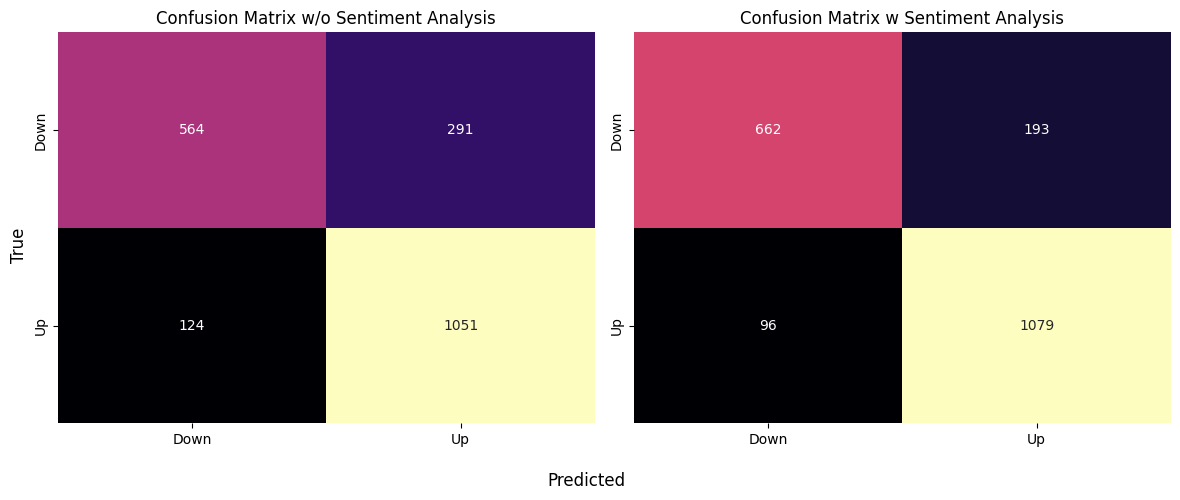

In [0]:
# Plot confusion matrices side-by-side to compare both models visually
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_wo_sent, ax=axes[0], cmap="magma", annot=True, fmt="d", cbar=False, xticklabels=["Down", "Up"], yticklabels=["Down", "Up"])
axes[0].set_title("Confusion Matrix w/o Sentiment Analysis")

sns.heatmap(cm_w_sent, ax=axes[1], cmap="magma", annot=True, fmt="d", cbar=False, xticklabels=["Down", "Up"], yticklabels=["Down", "Up"])
axes[1].set_title("Confusion Matrix w Sentiment Analysis")

fig.supxlabel("Predicted")
fig.supylabel("True")

plt.tight_layout()
plt.show()


## Feature-Target Correlation Matrix

To understand the relationships between engineered features and the 5-day forward price direction, we compute a **feature–target correlation matrix**. This analysis provides an interpretable, quantitative view of how each technical indicator and sentiment derived variable aligns with the future movement of AAPL’s stock price. While correlation alone is not a causal measure, it helps identify which features exhibit directional tendencies and which may contribute meaningful signal to downstream predictive models.

The matrix includes:

- **Technical indicators** such as RSI, SMA-normalized close, and SMA-normalized OBV differential. These features often show modest but consistent correlations with short-horizon returns, reflecting momentum, mean reversion, or volume price confirmation effects.

- **Sentiment features** derived from FinBERT, including dominant polarity, averaged confidence scores, and title/body sentiment splits. These allow us to quantify whether news tone exhibits any linear association with future price direction, offering a preliminary view before model-based nonlinear interactions are considered.

- **Binary Target** representing the 5-day future direction (up/down). Correlations with this target help highlight features with directional bias, though interpretation requires caution due to the discrete nature of the label.

Although gradient-boosted models like XGBoost capture nonlinear dependencies that correlation cannot, this analysis provides valuable intuition about signal structure, feature redundancy, and potential multicollinearity.

pandas Correlation Methods → https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html


12/05/2025 03:34:17 - INFO - 	 Received command c on object id p0


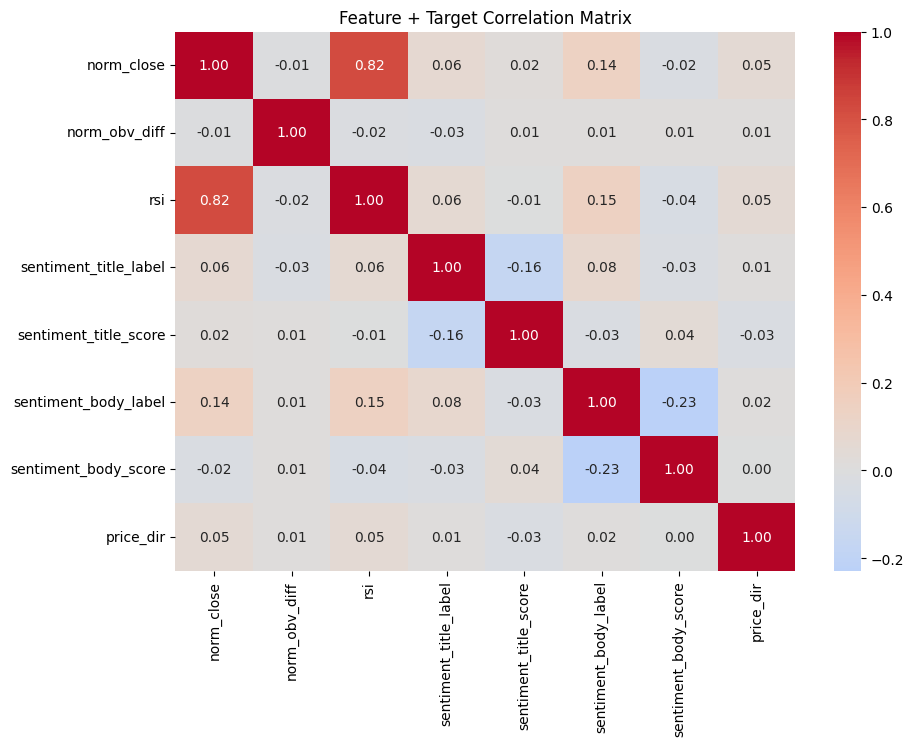

In [0]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Compute Pearson correlation between all features and target
corr = pd_df.corr()

# Heatmap to inspect relationships between features and price direction
plt.figure(figsize=(10, 7))
ax = sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", center=0)
ax.set_title("Feature + Target Correlation Matrix")
plt.show()

## Correctness Timeline Comparison: Technical-Only vs. Technical + Sentiment Models

To better understand how sentiment features influence short-horizon predictive accuracy, this visualization presents a correctness timeline for two XGBoost-based directional forecasting models. Rather than plotting binary up/down movements—which often results in visually noisy or ambiguous line charts—this method reduces the comparison to a sequence of correctness outcomes over time.

Each horizontal stripe represents one model’s performance against the actual 5-day price direction:

- **Model w/o Sentiment (Technical-Only)** — correctness of forecasts generated solely from SMA-normalized technical indicators.  
- **Model with Sentiment (Technical + FinBERT)** — correctness of forecasts enhanced with FinBERT-derived sentence- and article-level sentiment signals.

For every prediction window, the model output is evaluated against the true direction and encoded as:

- **1** → correct directional prediction  
- **0** → incorrect prediction  

These correctness sequences are displayed as heatmap-style strips aligned on a shared date axis, making it easy to see where models diverge, when sentiment contributes to improved stability, and how each responds to shifts in market conditions. Variations in color intensity reveal periods of stronger or weaker alignment with the actual trend, highlighting structural strengths and vulnerabilities within each modeling approach.


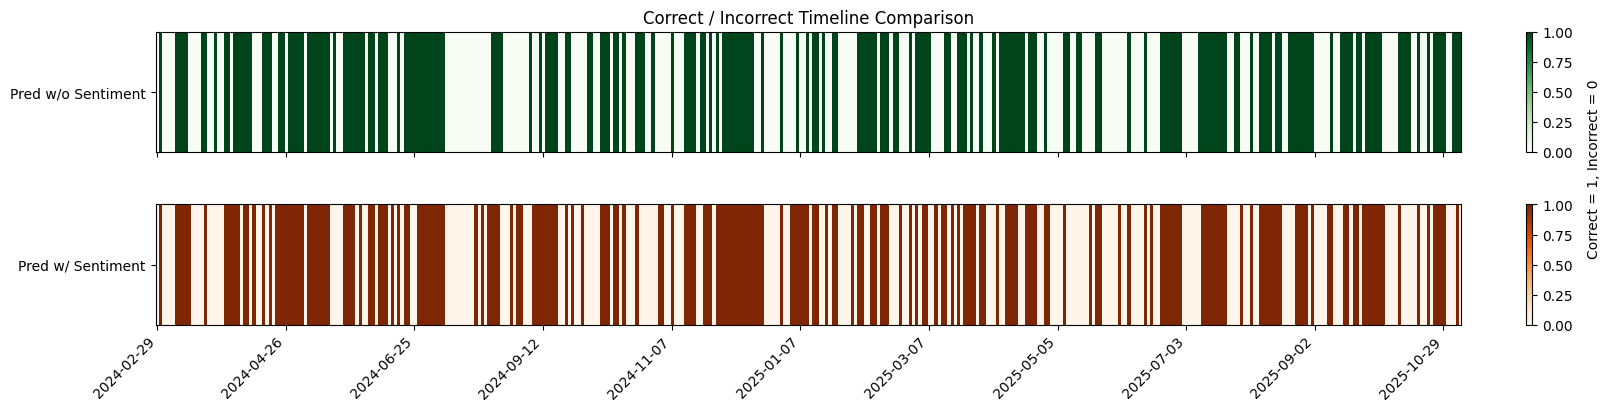

In [0]:
import matplotlib.pyplot as plt
import numpy as np

# correctness arrays (0 = wrong, 1 = correct)
correct_wo = (y1 == y2).astype(int)
correct_w  = (y1 == y3).astype(int)

# Convert to 2D arrays for imshow
stripe_wo = np.expand_dims(correct_wo.values, axis=0)
stripe_w  = np.expand_dims(correct_w.values, axis=0)

fig, axes = plt.subplots(2, 1, figsize=(16, 4), sharex=True, constrained_layout=True)

# --- Top stripe ---
im1 = axes[0].imshow(stripe_wo, aspect="auto", cmap="Greens", vmin=0, vmax=1)
axes[0].set_yticks([0])
axes[0].set_yticklabels(["Pred w/o Sentiment"])
axes[0].set_title("Correct / Incorrect Timeline Comparison")

# Colorbar beside top axis
cbar1 = fig.colorbar(im1, ax=axes[0], location='right')

# --- Bottom stripe ---
im2 = axes[1].imshow(stripe_w, aspect="auto", cmap="Oranges", vmin=0, vmax=1)
axes[1].set_yticks([0])
axes[1].set_yticklabels(["Pred w/ Sentiment"])

# Colorbar beside bottom axis
cbar2 = fig.colorbar(im2, ax=axes[1], location='right')
cbar2.set_label("Correct = 1, Incorrect = 0")
cbar2.ax.yaxis.set_label_coords(10, 1.3) 

# --- shared x-axis ticks ---
xticks = np.arange(0, len(y1), __builtins__.max(1, len(y1) // 10))
axes[1].set_xticks(xticks)

# Convert integer positions to actual datetime labels
tick_labels = [y1.index[i].strftime('%Y-%m-%d') for i in xticks]
axes[1].set_xticklabels(tick_labels, rotation=45, ha="right")

plt.show()



# Resources

1. [https://arxiv.org/pdf/2306.02136](https://arxiv.org/pdf/2306.02136)
2. [https://medium.com/prosus-ai-tech-blog/finbert-financial-sentiment-analysis-with-bert-b277a3607101](https://medium.com/prosus-ai-tech-blog/finbert-financial-sentiment-analysis-with-bert-b277a3607101)